# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [ ]:
# !pip install peft==0.13.2, transformers==4.41.1

In [ ]:
# !pip install wordcloud

In [ ]:
# !pip install imblearn

In [ ]:
# !pip install lightgbm

In [ ]:
# ============================================================
# Imports (organized + de-duplicated)
# ALBERT-focused notebook (hard/soft eval + training + plots)
# ============================================================

# -------------------------
# 1) Standard library
# -------------------------
import os
import re
import json
import time
import string
import random
import itertools
import warnings
from pathlib import Path
from dataclasses import dataclass
from collections import Counter
from typing import Any, Dict, Tuple, Optional

# -------------------------
# 2) Core DS stack
# -------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Optional visuals/text (keep only if used)
from wordcloud import WordCloud

# -------------------------
# 3) Stats / inference (keep only if used)
# -------------------------
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

# -------------------------
# 4) Scikit-learn
# -------------------------
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    accuracy_score,
    ConfusionMatrixDisplay,
)
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

# -------------------------
# 5) Persistence
# -------------------------
import joblib

# -------------------------
# 6) NLTK (keep only if used)
# -------------------------
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer

# -------------------------
# 7) PyTorch
# -------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# -------------------------
# 8) Transformers
# -------------------------
from transformers import AutoTokenizer, AlbertModel

# -------------------------
# 9) Notebook setup
# -------------------------
# If you're in a .py module, remove the next line.
%matplotlib inline

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# NLTK downloads (uncomment only if needed)
# nltk.download("stopwords")
# nltk.download("wordnet")
# nltk.download("punkt")

Device: cuda


## 1.2 Configuration

In [ ]:
import os
from pathlib import Path

# --- 1. Project & Path Settings ---
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/11_human"
RAW_DATA_FILE = "data/hatexplain_model_ready_with_ai_labels.csv"

# Output directory (inside project)
OUTPUT_DIR = "output"

# Filenames for trained model artifacts
ALBERT_MODEL_FILE = "best_albert_model_T52.pth"
ALBERT_PARAMS_FILE = "best_albert_params_soft_human_T52.json"

# --- 2. Dataset & Label Settings (SOFT LABELS ONLY: HUMAN 3-RATER VOTES) ---
TEXT_COLUMN = "text"

# Canonical class order for modeling (must match the soft-label columns you create)
CLASS_NAMES = ["normal", "offensive", "hate"]
N_CLASSES = len(CLASS_NAMES)

# Soft-label probability columns (HUMAN; created from label_id1/2/3)
SOFT_LABEL_COLUMNS = ["human_p_normal", "human_p_offensive", "human_p_hate"]

EXPECTED_LABEL_SOURCE = "human_votes_3rater"
LABEL_MODE = "soft"

# Human annotator raw columns (used to construct soft labels)
HUMAN_ANNOT_COLS = ["label_id1", "label_id2", "label_id3"]

# --- 3. Training & Tokenizer Settings ---
VOCAB_SIZE = 10000
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 32
N_ITERATIONS = 10
RANDOM_STATE = 42

# --- 4. Full Paths (Auto-generated) ---
RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)

OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

BEST_ALBERT_PATH = OUTPUT_PATH / ALBERT_MODEL_FILE
BEST_ALBERT_PARAMS_PATH = OUTPUT_PATH / ALBERT_PARAMS_FILE

print("--- Configuration Loaded (HUMAN soft labels | ALBERT) ---")
print(f"Project Path: {DRIVE_PROJECT_PATH}")
print(f"Raw Data Path: {RAW_DATA_PATH}")
print(f"Output Path: {OUTPUT_PATH}")
print(f"Label mode/source: {LABEL_MODE} / {EXPECTED_LABEL_SOURCE}")
print(f"Human annot cols: {HUMAN_ANNOT_COLS}")
print(f"Soft label cols: {SOFT_LABEL_COLUMNS}")
print(f"ALBERT Model Path: {BEST_ALBERT_PATH}")
print(f"ALBERT Params Path: {BEST_ALBERT_PARAMS_PATH}")

--- Configuration Loaded (HUMAN soft labels | ALBERT) ---
Project Path: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/11_human
Raw Data Path: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/11_human/data/hatexplain_model_ready_with_ai_labels.csv
Output Path: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/11_human/output
Label mode/source: soft / human_votes_3rater
Human annot cols: ['label_id1', 'label_id2', 'label_id3']
Soft label cols: ['human_p_normal', 'human_p_offensive', 'human_p_hate']
ALBERT Model Path: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/11_human/output/best_albert_model_T52.pth
ALBERT Params Path: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/11_human/output/best_albert_params_soft_human_T52.json


## 1.3 Load the data

In [ ]:
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


In [ ]:
# Load the raw data from our config path into a generic DataFrame
df_raw = pd.read_csv(RAW_DATA_PATH, index_col = 0)
print(f"Loaded raw data with {df_raw.shape[0]} rows.")

df_raw.head()

Loaded raw data with 20148 rows.


,text,label_id1,label_id2,label_id3,human_majority,is_pure,human_pure,ai_label_mini,ai_label_text_mini,ai_p_normal_mini,ai_p_offensive_mini,ai_p_hate_mini
id,,,,,,,,,,,,
1179055004553900032_twitter,i dont think im getting my baby them white 9 h...,normal,normal,normal,normal,True,normal,NORMAL,normal,0.90,0.1,0.00
1179063826874032128_twitter,we cannot continue calling ourselves feminists...,normal,normal,normal,normal,True,normal,NORMAL,normal,0.85,0.1,0.05
1178793830532956161_twitter,nawt yall niggers ignoring me,normal,normal,hatespeech,normal,False,NaN,HATE,hatespeech,0.00,0.1,0.90
1179088797964763136_twitter,<user> i am bit confused coz chinese ppl can n...,hatespeech,offensive,hatespeech,hatespeech,False,NaN,HATE,hatespeech,0.00,0.2,0.80
1179085312976445440_twitter,this bitch in whataburger eating a burger with...,hatespeech,hatespeech,offensive,hatespeech,False,NaN,HATE,hatespeech,0.00,0.1,0.90


# 2. Data Exploration \& Master Data Preparation

## 2.1 Data Preparation

In [ ]:
df_raw.shape

(20148, 12)

In [ ]:
# =========================
# Create HUMAN soft labels from 3 annotators (Option A)
# =========================

# 1) Basic checks
missing = [c for c in HUMAN_ANNOT_COLS if c not in df_raw.columns]
if missing:
    raise ValueError(f"Missing human annotator columns: {missing}")

# 2) Normalize human labels to canonical CLASS_NAMES
#    (HateXplain often uses 'hatespeech'; we map to 'hate')
def normalize_human_label(x):
    if pd.isna(x):
        return None
    x = str(x).strip().lower()

    mapping = {
        "hate speech": "hate",
        "hatespeech": "hate",
        "hate": "hate",
        "offensive": "offensive",
        "normal": "normal",
        "none": "normal",
        "neutral": "normal",
    }
    return mapping.get(x, x)

class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

def votes_to_soft(row) -> np.ndarray:
    counts = np.zeros(N_CLASSES, dtype=np.float32)
    valid = 0

    for col in HUMAN_ANNOT_COLS:
        lab = normalize_human_label(row[col])
        if lab is None:
            continue
        if lab not in class_to_idx:
            # Unknown label: skip (or raise if you'd rather catch issues early)
            continue
        counts[class_to_idx[lab]] += 1.0
        valid += 1

    # If no valid votes, fall back to uniform (rare; but safer than crashing mid-run)
    if valid == 0:
        return np.ones(N_CLASSES, dtype=np.float32) / N_CLASSES

    return counts / valid

# 3) Apply row-wise and expand into columns
human_soft = df_raw.apply(votes_to_soft, axis=1)   # Series of arrays length K
human_soft_mat = np.vstack(human_soft.to_numpy()) # [N, K]

df_raw[SOFT_LABEL_COLUMNS] = human_soft_mat

# 4) Create hard labels derived from soft targets (useful for split/eval)
df_raw["human_y_argmax"] = human_soft_mat.argmax(axis=1).astype(np.int64)
df_raw["human_y_name"] = df_raw["human_y_argmax"].map({i: CLASS_NAMES[i] for i in range(N_CLASSES)})

print("Created human soft label columns:", SOFT_LABEL_COLUMNS)
print(df_raw[SOFT_LABEL_COLUMNS].head())
print("\nArgmax distribution (diagnostic):")
print(df_raw["human_y_name"].value_counts())

# 5) Sanity checks
row_sums = df_raw[SOFT_LABEL_COLUMNS].sum(axis=1).to_numpy()
assert np.allclose(row_sums, 1.0, atol=1e-6), f"Soft labels do not sum to 1. Example sums: {row_sums[:10]}"

vals = df_raw[SOFT_LABEL_COLUMNS].to_numpy()
assert (vals >= -1e-8).all() and (vals <= 1 + 1e-8).all(), "Soft labels have values outside [0,1]."

# Optional: show a few rows where annotators disagreed (useful for debugging)
disagree_mask = df_raw[HUMAN_ANNOT_COLS].nunique(axis=1) > 1
print("\nExample disagreement rows:")
display(df_raw.loc[disagree_mask, HUMAN_ANNOT_COLS + SOFT_LABEL_COLUMNS].head(10))

Created human soft label columns: ['human_p_normal', 'human_p_offensive', 'human_p_hate']
                             human_p_normal  human_p_offensive  human_p_hate
id                                                                          
1179055004553900032_twitter        1.000000           0.000000      0.000000
1179063826874032128_twitter        1.000000           0.000000      0.000000
1178793830532956161_twitter        0.666667           0.000000      0.333333
1179088797964763136_twitter        0.000000           0.333333      0.666667
1179085312976445440_twitter        0.000000           0.333333      0.666667

Argmax distribution (diagnostic):
human_y_name
normal       8733
hate         5935
offensive    5480
Name: count, dtype: int64

Example disagreement rows:


,label_id1,label_id2,label_id3,human_p_normal,human_p_offensive,human_p_hate
id,,,,,,
1178793830532956161_twitter,normal,normal,hatespeech,0.666667,0.000000,0.333333
1179088797964763136_twitter,hatespeech,offensive,hatespeech,0.000000,0.333333,0.666667
1179085312976445440_twitter,hatespeech,hatespeech,offensive,0.000000,0.333333,0.666667
24198545_gab,hatespeech,hatespeech,offensive,0.000000,0.333333,0.666667
14567516_gab,offensive,hatespeech,offensive,0.000000,0.666667,0.333333
19679648_gab,hatespeech,hatespeech,normal,0.333333,0.000000,0.666667
15858421_gab,hatespeech,hatespeech,normal,0.333333,0.000000,0.666667
23844035_gab,hatespeech,hatespeech,normal,0.333333,0.000000,0.666667
1178905338386567168_twitter,normal,hatespeech,normal,0.666667,0.000000,0.333333


## 2.2 Master Data Preparation

In [ ]:
# --- Text Cleaning Function ---
def clean_text_master(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", "<URL>", text)
    text = re.sub(r"@\w+", "<USER>", text)
    text = re.sub(r"#\w+", "<HASHTAG>", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text_master)

Cleaning text...


Validating soft labels...
Master 'df_clean' created with 20148 rows.
Hard-label (argmax) distribution (for split diagnostics only):
y_hard_name
normal       8733
hate         5935
offensive    5480
Name: count, dtype: int64


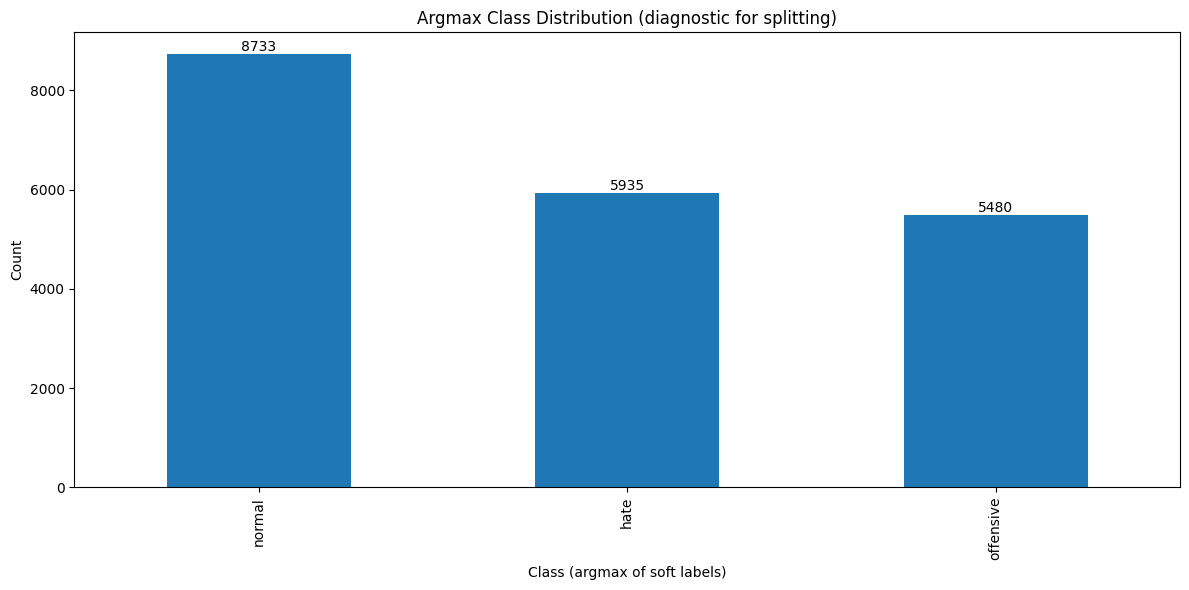

In [ ]:
# --- Soft-label checks + derived hard label for splitting/plots ---
print("Validating soft labels...")
missing_cols = [c for c in SOFT_LABEL_COLUMNS if c not in df_clean.columns]
if missing_cols:
    raise ValueError(f"Missing soft-label columns in CSV: {missing_cols}")

# Ensure numeric
df_clean[SOFT_LABEL_COLUMNS] = df_clean[SOFT_LABEL_COLUMNS].apply(pd.to_numeric, errors="coerce")

# Basic validity checks
if df_clean[SOFT_LABEL_COLUMNS].isna().any().any():
    bad_rows = df_clean[df_clean[SOFT_LABEL_COLUMNS].isna().any(axis=1)].head(5)
    raise ValueError(f"Found NaNs in soft labels. Example rows:\n{bad_rows[SOFT_LABEL_COLUMNS]}")

# Clip tiny floating noise and check sums
probs = df_clean[SOFT_LABEL_COLUMNS].to_numpy(dtype=float)
if (probs < -1e-6).any() or (probs > 1 + 1e-6).any():
    raise ValueError("Soft labels contain values outside [0,1] (beyond tolerance).")

row_sums = probs.sum(axis=1)
if not np.allclose(row_sums, 1.0, atol=1e-3):
    # If needed, renormalize instead of failing:
    # probs = probs / row_sums[:, None]
    # df_clean[SOFT_LABEL_COLUMNS] = probs
    raise ValueError(
        f"Soft label rows do not sum to 1 within tolerance. "
        f"Example sums: {row_sums[:10]}"
    )

# Create a temporary hard label (argmax) ONLY for stratification/plotting
df_clean["y_hard_argmax"] = probs.argmax(axis=1)
df_clean["y_hard_name"] = df_clean["y_hard_argmax"].map({i: CLASS_NAMES[i] for i in range(N_CLASSES)})

print(f"Master 'df_clean' created with {df_clean.shape[0]} rows.")
print("Hard-label (argmax) distribution (for split diagnostics only):")
print(df_clean["y_hard_name"].value_counts())

# Plot imbalance (diagnostic only)
plt.figure(figsize=(12, 6))
status_counts = df_clean["y_hard_name"].value_counts()
ax = status_counts.plot(kind="bar")
for i, v in enumerate(status_counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.title("Argmax Class Distribution (diagnostic for splitting)")
plt.xlabel("Class (argmax of soft labels)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.3 Master Data Split

### 2.3.1 Define groups for splitting

In [ ]:
groups = df_clean[TEXT_COLUMN]          # prevent same cleaned text across splits
y_for_split = df_clean["y_hard_argmax"] # approx stratification signal (not training target)

### 2.3.2. First split: train vs test

In [ ]:
gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)
train_idx, test_idx = next(gss_test.split(df_clean, y_for_split, groups=groups))

split = np.array(["train"] * len(df_clean), dtype=object)
split[test_idx] = "test"
df_clean["split"] = split

print("After train/test split:")
print(df_clean["split"].value_counts())

After train/test split:
split
train    16122
test      4026
Name: count, dtype: int64


### 2.3.3. Second split: train -> train + val (within train only)

In [ ]:
train_mask = df_clean["split"] == "train"
train_pos_indices = np.where(train_mask)[0]
df_train_only = df_clean.loc[train_mask].copy().reset_index(drop=True)

groups_train = df_train_only[TEXT_COLUMN]
y_train_for_split = df_train_only["y_hard_argmax"]

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,  # 0.25 of train => 0.20 of full
    random_state=RANDOM_STATE,
)

train_idx2, val_idx = next(gss_val.split(df_train_only, y_train_for_split, groups=groups_train))

train2_global = train_pos_indices[train_idx2]
val_global = train_pos_indices[val_idx]

split[:] = "train"
split[val_global] = "val"
split[test_idx] = "test"
df_clean["split"] = split

print("\nFinal split counts:")
print(df_clean["split"].value_counts())


Final split counts:
split
train    12096
val       4026
test      4026
Name: count, dtype: int64


### 2.3.4. Sanity checks

In [ ]:
# --- Leakage check: no text group appears in >1 split ---
group_split_counts = df_clean.groupby(TEXT_COLUMN)["split"].nunique()
n_leaky_groups = (group_split_counts > 1).sum()
print("\nNumber of text groups that appear in >1 split:", n_leaky_groups)
assert n_leaky_groups == 0, "Some text groups leak across splits!"

# --- Proportions ---
split_props = df_clean["split"].value_counts(normalize=True)
print("\nSplit proportions (approx):")
print(split_props)


Number of text groups that appear in >1 split: 0

Split proportions (approx):
split
train    0.600357
val      0.199821
test     0.199821
Name: proportion, dtype: float64


### 2.3.5. Save master split

In [ ]:
split_path = os.path.join(DRIVE_PROJECT_PATH, "output/hatexplain_master_split_soft_4omini.csv")
df_clean.to_csv(split_path, index=False)
print("\nSaved master split to:", split_path)


Saved master split to: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/11_human/output/hatexplain_master_split_soft_4omini.csv


# 3. ALBERT Model with Soft Labels


## 3.0 Define evaluation function for DL models

In [ ]:
# -----------------------------
# 1) Generic bootstrap CI engine
# -----------------------------
def bootstrap_ci_mean(values: np.ndarray, n_iterations: int = 1000) -> Tuple[float, float, float]:
    """
    Bootstrap CI for the MEAN of a per-sample metric array.
    Returns: (mean, ci_low, ci_high).
    """
    values = np.asarray(values, dtype=np.float64)
    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan

    idx_all = np.arange(n)
    boot_means = []
    for _ in range(n_iterations):
        idx = resample(idx_all)
        boot_means.append(values[idx].mean())

    boot_means = np.asarray(boot_means, dtype=np.float64)
    return float(values.mean()), float(np.percentile(boot_means, 2.5)), float(np.percentile(boot_means, 97.5))


# -----------------------------
# 2) Bootstrap CI for HARD metrics
# -----------------------------
def bootstrap_f1_ci(y_true, y_pred, n_iterations: int = 1000, average: str = "weighted") -> Tuple[float, float, float]:
    """
    Bootstrap CI for F1 (computed on each bootstrap resample).
    Returns: (mean, ci_low, ci_high).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    f1_scores = []
    idx_all = np.arange(len(y_true))

    for _ in range(n_iterations):
        idx = resample(idx_all)
        try:
            f1_scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue

    if not f1_scores:
        return np.nan, np.nan, np.nan

    f1_scores = np.asarray(f1_scores, dtype=np.float64)
    return float(f1_scores.mean()), float(np.percentile(f1_scores, 2.5)), float(np.percentile(f1_scores, 97.5))


def bootstrap_auc_ci_multiclass(
    y_true,
    y_scores,
    n_iterations: int = 1000,
    average: str = "macro",
) -> Tuple[float, float, float]:
    """
    Bootstrap CI for multi-class AUC (OVR).
    y_true: [N] int labels
    y_scores: [N, K] probabilities
    Returns: (mean, ci_low, ci_high).
    """
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)

    auc_scores = []
    idx_all = np.arange(len(y_true))

    for _ in range(n_iterations):
        idx = resample(idx_all)
        y_t = y_true[idx]
        y_s = y_scores[idx]
        try:
            auc_scores.append(
                roc_auc_score(y_t, y_s, average=average, multi_class="ovr")
            )
        except ValueError:
            continue

    if not auc_scores:
        return np.nan, np.nan, np.nan

    auc_scores = np.asarray(auc_scores, dtype=np.float64)
    return float(auc_scores.mean()), float(np.percentile(auc_scores, 2.5)), float(np.percentile(auc_scores, 97.5))


# -----------------------------
# 3) Soft metrics (per-sample + CI)
# -----------------------------
def per_sample_soft_ce_from_probs(
    probs_np: np.ndarray,
    soft_targets_np: np.ndarray,
    eps: float = 1e-12
) -> np.ndarray:
    """
    Per-sample Soft CE: -sum_k soft_k * log(p_k)
    probs_np: [N,K]
    soft_targets_np: [N,K]
    """
    probs = np.clip(np.asarray(probs_np, dtype=np.float64), eps, 1.0)
    soft = np.asarray(soft_targets_np, dtype=np.float64)
    return -np.sum(soft * np.log(probs), axis=1)


def per_sample_brier(
    probs_np: np.ndarray,
    soft_targets_np: np.ndarray
) -> np.ndarray:
    """
    Per-sample multiclass Brier: sum_k (p_k - soft_k)^2
    probs_np: [N,K]
    soft_targets_np: [N,K]
    """
    probs = np.asarray(probs_np, dtype=np.float64)
    soft = np.asarray(soft_targets_np, dtype=np.float64)
    return np.sum((probs - soft) ** 2, axis=1)


def bootstrap_soft_ce_ci(
    probs_np: np.ndarray,
    soft_targets_np: np.ndarray,
    n_iterations: int = 1000
) -> Tuple[float, float, float]:
    """
    Bootstrap CI for mean Soft CE.
    """
    values = per_sample_soft_ce_from_probs(probs_np, soft_targets_np)
    return bootstrap_ci_mean(values, n_iterations=n_iterations)


def bootstrap_brier_ci(
    probs_np: np.ndarray,
    soft_targets_np: np.ndarray,
    n_iterations: int = 1000
) -> Tuple[float, float, float]:
    """
    Bootstrap CI for mean Brier.
    """
    values = per_sample_brier(probs_np, soft_targets_np)
    return bootstrap_ci_mean(values, n_iterations=n_iterations)


# -----------------------------
# 4) Plots
# -----------------------------
def plot_confusion_matrix_named(
    y_true,
    y_pred,
    class_names,
    model_name: str = "Model",
    save_dir: Optional[str] = None,
    cmap_name: str = "Blues"
):
    labels_idx = list(range(len(class_names)))
    cm = confusion_matrix(y_true, y_pred, labels=labels_idx)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap_name,
        xticklabels=class_names,
        yticklabels=class_names,
        vmin=0,
        vmax=cm.max() if cm.size else 1,
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{model_name}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved confusion matrix to: {path}")

    plt.show()


def plot_multiclass_roc_named(
    y_true,
    y_score,
    class_names,
    label_prefix: str = "Model",
    save_dir: Optional[str] = None
):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    n_classes = len(class_names)

    classes_idx = np.arange(n_classes)
    y_true_bin = label_binarize(y_true, classes=classes_idx)

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", n_classes)
    plt.figure(figsize=(10, 8))
    for i, (name, color) in enumerate(zip(class_names, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f"{name} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{label_prefix} - Multi-class ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{label_prefix}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved ROC curve to: {path}")

    plt.show()

# -----------------------------
# 5) High-level evaluators
# -----------------------------
def evaluate_logits_hard(
    y_true_hard: np.ndarray,
    logits_np: np.ndarray,
    class_names: list,
    n_boot: int = 1000,
    average_f1: str = "weighted",
    average_auc: str = "macro",
    model_tag: str = "MODEL",
    save_dir: Optional[str] = None,
    do_plots: bool = True,
) -> Dict[str, Any]:
    """
    Hard evaluation from logits:
      - preds from argmax
      - probs from softmax
      - report + bootstrap CI + optional plots
    """
    y_true_hard = np.asarray(y_true_hard, dtype=np.int64)
    logits_np = np.asarray(logits_np, dtype=np.float64)

    probs = torch.softmax(torch.tensor(logits_np, dtype=torch.float32), dim=1).numpy()
    preds = probs.argmax(axis=1)

    print(f"\n--- Evaluation (HARD): {model_tag} ---\n")
    print(
        classification_report(
            y_true_hard,
            preds,
            labels=list(range(len(class_names))),
            target_names=class_names,
            digits=4,
            zero_division=0,
        )
    )

    f1_mean, f1_low, f1_high = bootstrap_f1_ci(y_true_hard, preds, n_iterations=n_boot, average=average_f1)
    auc_mean, auc_low, auc_high = bootstrap_auc_ci_multiclass(y_true_hard, probs, n_iterations=n_boot, average=average_auc)

    print(f"Weighted F1: {f1_mean:.4f}  |  95% CI: [{f1_low:.4f}, {f1_high:.4f}]")
    print(f"Macro AUC(OVR): {auc_mean:.4f} |  95% CI: [{auc_low:.4f}, {auc_high:.4f}]")

    if do_plots:
        plot_confusion_matrix_named(y_true_hard, preds, class_names, model_name=model_tag, save_dir=save_dir)
        plot_multiclass_roc_named(y_true_hard, probs, class_names, label_prefix=model_tag, save_dir=save_dir)

    return {
        "y_true": y_true_hard,
        "y_pred": preds,
        "y_prob": probs,
        "f1_weighted": float(f1_mean),
        "f1_ci": (float(f1_low), float(f1_high)),
        "auc_macro_ovr": float(auc_mean),
        "auc_ci": (float(auc_low), float(auc_high)),
    }


def evaluate_probs_soft(
    probs_np: np.ndarray,
    y_true_soft: np.ndarray,
    n_boot: int = 1000,
    model_tag: str = "MODEL",
) -> Dict[str, Any]:
    """
    Soft evaluation from probs:
      - soft CE + CI
      - brier + CI
    """
    probs_np = np.asarray(probs_np, dtype=np.float64)
    y_true_soft = np.asarray(y_true_soft, dtype=np.float64)

    soft_ce_mean, soft_ce_low, soft_ce_high = bootstrap_soft_ce_ci(probs_np, y_true_soft, n_iterations=n_boot)
    brier_mean, brier_low, brier_high = bootstrap_brier_ci(probs_np, y_true_soft, n_iterations=n_boot)

    print(f"\n--- Evaluation (SOFT): {model_tag} ---\n")
    print(f"Soft CE: {soft_ce_mean:.6f}  |  95% CI: [{soft_ce_low:.6f}, {soft_ce_high:.6f}]")
    print(f"Brier:   {brier_mean:.6f}   |  95% CI: [{brier_low:.6f}, {brier_high:.6f}]")

    return {
        "soft_ce": float(soft_ce_mean),
        "soft_ce_ci": (float(soft_ce_low), float(soft_ce_high)),
        "brier": float(brier_mean),
        "brier_ci": (float(brier_low), float(brier_high)),
    }

## 3.1 Data Preprocessing

### Step 1: Build train/val/test splits for ALBERT

In [ ]:
# Build split dfs
df_train = df_clean[df_clean["split"] == "train"].copy()
df_val   = df_clean[df_clean["split"] == "val"].copy()
df_test  = df_clean[df_clean["split"] == "test"].copy()

### Step 2: Build texts + soft labels

In [ ]:
train_texts = df_train[TEXT_COLUMN].astype(str).tolist()
val_texts   = df_val[TEXT_COLUMN].astype(str).tolist()
test_texts  = df_test[TEXT_COLUMN].astype(str).tolist()

def normalize_rows(P: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    P = np.asarray(P, dtype=np.float32)
    s = P.sum(axis=1, keepdims=True)
    return P / np.clip(s, eps, None)

def _get_soft(df: pd.DataFrame) -> np.ndarray:
    soft = df[SOFT_LABEL_COLUMNS].to_numpy(dtype=np.float32)
    return normalize_rows(soft)

y_train_soft = _get_soft(df_train)
y_val_soft   = _get_soft(df_val)
y_test_soft  = _get_soft(df_test)

# "Hardified" labels for interpretability only (NOT primary training target)
y_train_hard = y_train_soft.argmax(axis=1).astype(np.int64)
y_val_hard   = y_val_soft.argmax(axis=1).astype(np.int64)
y_test_hard  = y_test_soft.argmax(axis=1).astype(np.int64)

print("Train soft:", y_train_soft.shape, "Val soft:", y_val_soft.shape, "Test soft:", y_test_soft.shape)
print("Val hard dist:", np.bincount(y_val_hard, minlength=N_CLASSES))
print("Test hard dist:", np.bincount(y_test_hard, minlength=N_CLASSES))

Train soft: (12096, 3) Val soft: (4026, 3) Test soft: (4026, 3)
Val hard dist: [1729 1082 1215]
Test hard dist: [1763 1127 1136]


## 3.2 Model Construction

### 3.2.1 Utilities: seed + device

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def normalize_rows(P: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    P = np.asarray(P, dtype=np.float32)
    s = P.sum(axis=1, keepdims=True)
    return P / np.clip(s, eps, None)

def soft_cross_entropy_torch(logits: torch.Tensor, soft_targets: torch.Tensor) -> torch.Tensor:
    logp = F.log_softmax(logits, dim=1)
    return -(soft_targets * logp).sum(dim=1).mean()

def soft_ce_from_logits_np(logits_np: np.ndarray, soft_targets_np: np.ndarray) -> float:
    logits = torch.tensor(logits_np, dtype=torch.float32)
    soft_t = torch.tensor(soft_targets_np, dtype=torch.float32)
    logp = F.log_softmax(logits, dim=1)
    return float((-(soft_t * logp).sum(dim=1).mean()).item())

def brier_from_probs_np(probs_np: np.ndarray, soft_targets_np: np.ndarray) -> float:
    probs_np = np.asarray(probs_np, dtype=np.float32)
    soft_targets_np = np.asarray(soft_targets_np, dtype=np.float32)
    return float(np.mean(np.sum((probs_np - soft_targets_np) ** 2, axis=1)))

def hard_metrics_from_logits(y_true_hard: np.ndarray, logits_np: np.ndarray) -> Dict[str, float]:
    y_true_hard = np.asarray(y_true_hard, dtype=np.int64)
    preds = logits_np.argmax(axis=1)
    f1w = f1_score(y_true_hard, preds, average="weighted")
    f1m = f1_score(y_true_hard, preds, average="macro")

    probs = torch.softmax(torch.tensor(logits_np, dtype=torch.float32), dim=1).numpy()
    try:
        auc_ovr = roc_auc_score(y_true_hard, probs, multi_class="ovr")
    except Exception:
        auc_ovr = np.nan

    return {"f1_weighted": float(f1w), "f1_macro": float(f1m), "auc_ovr": float(auc_ovr)}

### 3.2.2 Dataset

In [ ]:
class AlbertSoftDataset(Dataset):
    """
    Always returns:
      - input_ids, attention_mask
      - soft_labels (if provided)
      - labels (hard; argmax of soft) if provided or derivable
    """
    def __init__(self, texts, soft_labels=None, hard_labels=None, tokenizer=None, max_len=128):
        self.texts = list(texts)
        self.tokenizer = tokenizer
        self.max_len = int(max_len)

        self.soft_labels = None if soft_labels is None else normalize_rows(np.asarray(soft_labels, dtype=np.float32))
        if hard_labels is not None:
            self.hard_labels = np.asarray(hard_labels, dtype=np.int64)
        elif self.soft_labels is not None:
            self.hard_labels = self.soft_labels.argmax(axis=1).astype(np.int64)
        else:
            self.hard_labels = None

        if self.soft_labels is not None:
            assert self.soft_labels.shape[1] == N_CLASSES, f"Soft label K mismatch: {self.soft_labels.shape}"

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
        }
        if self.hard_labels is not None:
            item["labels"] = torch.tensor(self.hard_labels[idx], dtype=torch.long)
        if self.soft_labels is not None:
            item["soft_labels"] = torch.tensor(self.soft_labels[idx], dtype=torch.float32)
        return item


### 3.2.3 Model

In [ ]:
class AlbertClassifier(nn.Module):
    def __init__(
        self,
        model_name="albert-base-v2",
        num_classes=3,
        dropout=0.1,
        hidden_dim=None,
        freeze_base=False
    ):
        super().__init__()
        self.base = AlbertModel.from_pretrained(model_name)
        hs = self.base.config.hidden_size

        if freeze_base:
            for p in self.base.parameters():
                p.requires_grad = False

        self.dropout = nn.Dropout(dropout)
        self.use_hidden = hidden_dim is not None

        if self.use_hidden:
            self.fc1 = nn.Linear(hs, hidden_dim)
            self.act = nn.ReLU()
            self.fc2 = nn.Linear(hidden_dim, num_classes)
        else:
            self.fc = nn.Linear(hs, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.base(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        x = self.dropout(cls)
        if self.use_hidden:
            x = self.fc1(x)
            x = self.act(x)
            x = self.dropout(x)
            logits = self.fc2(x)
        else:
            logits = self.fc(x)
        return logits


### 3.2.4 Losses + metrics

In [ ]:
@dataclass
class TrainResult:
    model: nn.Module
    tokenizer: Any
    best_params: Dict[str, Any]
    best_val_soft_loss: float
    best_epoch: int
    history: Dict[str, list]


def predict_logits(model, loader, device) -> Tuple[np.ndarray, Optional[np.ndarray], Optional[np.ndarray]]:
    model.eval()
    all_logits, all_hard, all_soft = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            logits = model(input_ids, attn)
            all_logits.append(logits.detach().cpu().numpy())

            if "labels" in batch:
                all_hard.append(batch["labels"].cpu().numpy())
            if "soft_labels" in batch:
                all_soft.append(batch["soft_labels"].cpu().numpy())

    logits_np = np.concatenate(all_logits, axis=0)
    hard_np = np.concatenate(all_hard, axis=0) if all_hard else None
    soft_np = np.concatenate(all_soft, axis=0) if all_soft else None
    return logits_np, hard_np, soft_np

### 3.2.5 Train loop (soft train, hard-val early stopping on weighted F1)

In [ ]:
def train_one_config_softsoftsoft(
    train_texts, y_train_soft,
    val_texts, y_val_soft,
    model_name="albert-base-v2",
    num_classes=3,
    max_len=128,
    batch_size=BATCH_SIZE,
    num_epochs=6,
    lr=2e-5,
    dropout=0.1,
    hidden_dim=None,
    freeze_base=False,
    seed=42,
) -> Tuple[nn.Module, Any, Dict[str, float], Dict[str, list]]:

    set_seed(seed)
    device = get_device()
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_ds = AlbertSoftDataset(train_texts, soft_labels=y_train_soft, tokenizer=tokenizer, max_len=max_len)
    val_ds   = AlbertSoftDataset(val_texts,   soft_labels=y_val_soft,   tokenizer=tokenizer, max_len=max_len)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    model = AlbertClassifier(
        model_name=model_name,
        num_classes=num_classes,
        dropout=dropout,
        hidden_dim=hidden_dim,
        freeze_base=freeze_base
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    history = {"train_soft_loss": [], "val_soft_loss": [], "val_f1w_argmax": []}

    best_val = np.inf
    best_state = None
    best_epoch = -1

    for epoch in range(1, num_epochs + 1):
        # ---- train (soft) ----
        model.train()
        train_losses = []
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            soft = batch["soft_labels"].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attn)
            loss = soft_cross_entropy_torch(logits, soft)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        train_soft_loss = float(np.mean(train_losses))

        # ---- val (soft) ----
        model.eval()
        val_losses = []
        all_val_logits = []
        all_val_hard = []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attn = batch["attention_mask"].to(device)
                soft = batch["soft_labels"].to(device)
                hard = batch["labels"].to(device)  # argmax(soft), for reporting

                logits = model(input_ids, attn)
                loss = soft_cross_entropy_torch(logits, soft)
                val_losses.append(loss.item())

                all_val_logits.append(logits.detach().cpu().numpy())
                all_val_hard.append(hard.detach().cpu().numpy())

        val_soft_loss = float(np.mean(val_losses))
        val_logits_np = np.concatenate(all_val_logits, axis=0)
        val_hard_np = np.concatenate(all_val_hard, axis=0)

        val_hard_metrics = hard_metrics_from_logits(val_hard_np, val_logits_np)
        val_f1w = val_hard_metrics["f1_weighted"]

        history["train_soft_loss"].append(train_soft_loss)
        history["val_soft_loss"].append(val_soft_loss)
        history["val_f1w_argmax"].append(val_f1w)

        print(
            f"Epoch {epoch}/{num_epochs} | "
            f"TrainSoftLoss={train_soft_loss:.4f} | ValSoftLoss={val_soft_loss:.4f} | "
            f"ValF1(w,argmax)={val_f1w:.4f}"
        )

        # Best selection on VAL SOFT LOSS (proper scoring rule); no early stopping
        if val_soft_loss < best_val:
            best_val = val_soft_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch

    if best_state is not None:
        model.load_state_dict(best_state)

    metrics = {"best_val_soft_loss": float(best_val), "best_epoch": int(best_epoch)}
    return model, tokenizer, metrics, history

### 3.2.6 Random search over grid

In [ ]:
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def random_search_albert_softsoftsoft(
    train_texts, y_train_soft,
    val_texts, y_val_soft,
    n_iter: int,
    model_name="albert-base-v2",
    num_classes=3,
    max_len=128,
    batch_size=BATCH_SIZE,          # fixed
    hidden_dim=None,        # fixed
    freeze_base=False,      # fixed
    seed=SEED,
    select_by: str = "val_soft_loss",   # "val_soft_loss" (recommended) or "val_f1w_argmax"
    best_model_path=None,              # e.g., BEST_ALBERT_PATH
) -> TrainResult:
    """
    Continuous random search:
      - lr: log-uniform in [1e-5, 3e-5]
      - epochs: np.random.randint(3, 6)  -> yields 3,4,5
      - dropout: uniform in [0.0, 0.25]

    Selection:
      - select_by="val_soft_loss": minimize best_val_soft_loss
      - select_by="val_f1w_argmax": maximize val_f1w computed vs argmax(soft) labels (proxy hard)
    """

    # random search space
    param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (3, 6),        # NOTE: randint(3,6) gives 3,4,5
        "dropout": (0.0, 0.25),
    }

    best_model = None
    best_tokenizer = None
    best_params = None
    best_history = None
    best_epoch = -1

    if select_by == "val_soft_loss":
        best_score = np.inf
    elif select_by == "val_f1w_argmax":
        best_score = -np.inf
    else:
        raise ValueError("select_by must be 'val_soft_loss' or 'val_f1w_argmax'")

    with tqdm(total=n_iter, desc="Random Search Tuning", leave=True) as pbar:
        for _ in range(n_iter):
            # sample hyperparameters
            hyperparams = {
                "lr": 10 ** np.random.uniform(*param_space["lr"]),
                "num_epochs": int(np.random.randint(*param_space["epochs"])),
                "dropout": float(np.random.uniform(*param_space["dropout"])),
            }

            model, tokenizer, metrics, history = train_one_config_softsoftsoft(
                train_texts=train_texts,
                y_train_soft=y_train_soft,
                val_texts=val_texts,
                y_val_soft=y_val_soft,
                model_name=model_name,
                num_classes=num_classes,
                max_len=max_len,
                batch_size=batch_size,
                num_epochs=hyperparams["num_epochs"],
                lr=hyperparams["lr"],
                dropout=hyperparams["dropout"],
                hidden_dim=hidden_dim,
                freeze_base=freeze_base,
                seed=seed,
            )

            val_soft_loss = float(metrics["best_val_soft_loss"])
            val_epoch = int(metrics["best_epoch"])

            # history contains per-epoch val_f1w_argmax
            if history.get("val_f1w_argmax"):
                idx = max(val_epoch - 1, 0)
                val_f1w_best_epoch = float(history["val_f1w_argmax"][idx])
                val_f1w_last = float(history["val_f1w_argmax"][-1])
            else:
                val_f1w_best_epoch = np.nan
                val_f1w_last = np.nan

            # select best trial
            if select_by == "val_soft_loss":
                is_best = val_soft_loss < best_score
                score_display = val_soft_loss
            else:
                is_best = val_f1w_best_epoch > best_score
                score_display = val_f1w_best_epoch

            if is_best:
                best_score = score_display
                best_model = model
                best_tokenizer = tokenizer
                best_params = hyperparams
                best_epoch = val_epoch
                best_history = history

                if best_model_path is not None:
                    torch.save(best_model.state_dict(), str(best_model_path))

            # progress display
            if select_by == "val_soft_loss":
                pbar.set_postfix(val_soft_loss=val_soft_loss, val_f1w_last=val_f1w_last)
            else:
                pbar.set_postfix(val_f1w=val_f1w_best_epoch, val_soft_loss=val_soft_loss)

            pbar.update(1)

    if best_model is None:
        raise RuntimeError("No successful ALBERT configuration found.")

    # report best_val_soft_loss coherently
    if select_by == "val_soft_loss":
        best_val_soft_loss = float(best_score)
    else:
        idx = max(best_epoch - 1, 0)
        best_val_soft_loss = float(best_history["val_soft_loss"][idx])

    return TrainResult(
        model=best_model,
        tokenizer=best_tokenizer,
        best_params=best_params,
        best_val_soft_loss=float(best_val_soft_loss),
        best_epoch=int(best_epoch),
        history=best_history,
    )


# =========================
# Example call
# =========================
start_time = time.time()

result = random_search_albert_softsoftsoft(
    train_texts=train_texts,
    y_train_soft=y_train_soft,
    val_texts=val_texts,
    y_val_soft=y_val_soft,
    n_iter=N_ITERATIONS,
    model_name="albert-base-v2",
    num_classes=N_CLASSES,
    max_len=MAX_TOKEN_LENGTH,
    batch_size=BATCH_SIZE,
    hidden_dim=None,
    freeze_base=False,
    seed=RANDOM_STATE,
    select_by="val_soft_loss",
    best_model_path=BEST_ALBERT_PATH,
)

end_time = time.time()
print(f"Total Parameter Tuning Time: {end_time - start_time:.2f} seconds")

best_model = result.model
best_tokenizer = result.tokenizer
best_params = result.best_params

print("\nBest params:", best_params)
print("Best val soft loss:", result.best_val_soft_loss, "at epoch", result.best_epoch)

Random Search Tuning:   0%|          | 0/10 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/5 | TrainSoftLoss=0.9849 | ValSoftLoss=0.8881 | ValF1(w,argmax)=0.6110
Epoch 2/5 | TrainSoftLoss=0.8497 | ValSoftLoss=0.8716 | ValF1(w,argmax)=0.6406
Epoch 3/5 | TrainSoftLoss=0.7773 | ValSoftLoss=0.8716 | ValF1(w,argmax)=0.6390
Epoch 4/5 | TrainSoftLoss=0.7191 | ValSoftLoss=0.9038 | ValF1(w,argmax)=0.6392


Random Search Tuning:  10%|█         | 1/10 [08:37<1:17:40, 517.78s/it, val_f1w_last=0.636, val_soft_loss=0.872]

Epoch 5/5 | TrainSoftLoss=0.6718 | ValSoftLoss=0.9384 | ValF1(w,argmax)=0.6363


...

Epoch 3/3 | TrainSoftLoss=0.7627 | ValSoftLoss=0.8724 | ValF1(w,argmax)=0.6311


AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3 | TrainSoftLoss=0.9691 | ValSoftLoss=0.8788 | ValF1(w,argmax)=0.6276
Epoch 2/3 | TrainSoftLoss=0.8402 | ValSoftLoss=0.8649 | ValF1(w,argmax)=0.6427


Random Search Tuning: 100%|██████████| 10/10 [54:55<00:00, 329.59s/it, val_f1w_last=0.631, val_soft_loss=0.865]

Epoch 3/3 | TrainSoftLoss=0.7627 | ValSoftLoss=0.8724 | ValF1(w,argmax)=0.6311
Total Parameter Tuning Time: 3295.94 seconds

Best params: {'lr': 1.5090410414033428e-05, 'num_epochs': 3, 'dropout': 0.04585869746654095}
Best val soft loss: 0.8648766651749611 at epoch 2


In [ ]:
torch.save(best_model.state_dict(), str(BEST_ALBERT_PATH))
with open(BEST_ALBERT_PARAMS_PATH, "w") as f:
    json.dump(best_params, f, indent=2)

print(f"Saved model to: {BEST_ALBERT_PATH}")
print(f"Saved params to: {BEST_ALBERT_PARAMS_PATH}")

Saved model to: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/11_human/output/best_albert_model_T52.pth
Saved params to: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/11_human/output/best_albert_params_soft_human_T52.json


## 3.3 Predict + evaluate on test

In [ ]:
def reconstruct_and_evaluate_best_albert_with_ci(
    model_path,
    params_path,
    test_texts,
    y_test_hard,
    class_names,
    max_len,
    batch_size=BATCH_SIZE,
    model_name="albert-base-v2",
    save_dir=None,
):
    device = get_device()

    best_params_disk = None
    if params_path is not None and os.path.exists(str(params_path)):
        with open(str(params_path), "r") as f:
            best_params_disk = json.load(f)

    dropout = float(best_params_disk["dropout"]) if best_params_disk and "dropout" in best_params_disk else 0.1
    hidden_dim = best_params_disk.get("hidden_dim", None) if best_params_disk else None
    freeze_base = bool(best_params_disk.get("freeze_base", False)) if best_params_disk else False

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    model = AlbertClassifier(
        model_name=model_name,
        num_classes=len(class_names),
        dropout=dropout,
        hidden_dim=hidden_dim,
        freeze_base=freeze_base,
    ).to(device)

    state = torch.load(str(model_path), map_location=device)
    model.load_state_dict(state)
    model.eval()

    print("Loaded model from:", str(model_path))
    print("Reconstructed with:", {"dropout": dropout, "hidden_dim": hidden_dim, "freeze_base": freeze_base})

    test_ds = AlbertSoftDataset(
        test_texts,
        hard_labels=y_test_hard,
        soft_labels=None,
        tokenizer=tokenizer,
        max_len=max_len,
    )
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    test_logits, test_y, _ = predict_logits(model, test_loader, device=device)

    hard_out = evaluate_logits_hard(
        y_true_hard=test_y,
        logits_np=test_logits,
        class_names=class_names,
        n_boot=1000,
        model_tag="BEST_ALBERT_FROM_DISK",
        save_dir=save_dir,
        do_plots=True,
    )

    hard_out["reconstruct_params"] = {"dropout": dropout, "hidden_dim": hidden_dim, "freeze_base": freeze_base}
    return hard_out

In [ ]:
# ============================================================
# Generate: test_logits, test_y_hard, test_y_soft (and probs)
# ============================================================

device = get_device()

# Build TEST dataset/loader (returns both labels + soft_labels if you pass both)
test_ds = AlbertSoftDataset(
    texts=test_texts,
    soft_labels=y_test_soft,          # [N,K]
    hard_labels=y_test_hard,          # [N] int (can be argmax(soft) or true hard)
    tokenizer=best_tokenizer,
    max_len=MAX_TOKEN_LENGTH,
)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Predict logits + labels (uses your existing predict_logits)
test_logits, test_y_hard, test_y_soft = predict_logits(
    best_model.to(device),
    test_loader,
    device=device
)

# Convert logits -> probabilities
test_probs = torch.softmax(torch.tensor(test_logits, dtype=torch.float32), dim=1).numpy()

print("test_logits shape:", test_logits.shape)     # (N, K)
print("test_y_hard shape:", test_y_hard.shape)     # (N,)
print("test_y_soft shape:", test_y_soft.shape)     # (N, K)
print("test_probs shape:", test_probs.shape)       # (N, K)


# ============================================================
# Generate: val_logits, val_y_hard, val_y_soft (and probs)
# ============================================================

val_ds = AlbertSoftDataset(
    texts=val_texts,
    soft_labels=y_val_soft,
    hard_labels=y_val_hard,
    tokenizer=best_tokenizer,
    max_len=MAX_TOKEN_LENGTH,
)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

val_logits, val_y_hard, val_y_soft = predict_logits(
    best_model.to(device),
    val_loader,
    device=device
)

val_probs = torch.softmax(torch.tensor(val_logits, dtype=torch.float32), dim=1).numpy()

print("val_logits shape:", val_logits.shape)
print("val_y_hard shape:", val_y_hard.shape)
print("val_y_soft shape:", val_y_soft.shape)
print("val_probs shape:", val_probs.shape)

test_logits shape: (4026, 3)
test_y_hard shape: (4026,)
test_y_soft shape: (4026, 3)
test_probs shape: (4026, 3)
val_logits shape: (4026, 3)
val_y_hard shape: (4026,)
val_y_soft shape: (4026, 3)
val_probs shape: (4026, 3)



--- Evaluation (HARD): ALBERT_TEST ---

              precision    recall  f1-score   support

      normal     0.6634    0.8117    0.7301      1763
   offensive     0.5664    0.3594    0.4397      1127
        hate     0.7002    0.7113    0.7057      1136

    accuracy                         0.6567      4026
   macro avg     0.6433    0.6274    0.6252      4026
weighted avg     0.6466    0.6567    0.6419      4026

Weighted F1: 0.6417  |  95% CI: [0.6270, 0.6572]
Macro AUC(OVR): 0.8123 |  95% CI: [0.8018, 0.8221]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/11_human/output/ALBERT_TEST_confusion_matrix.png


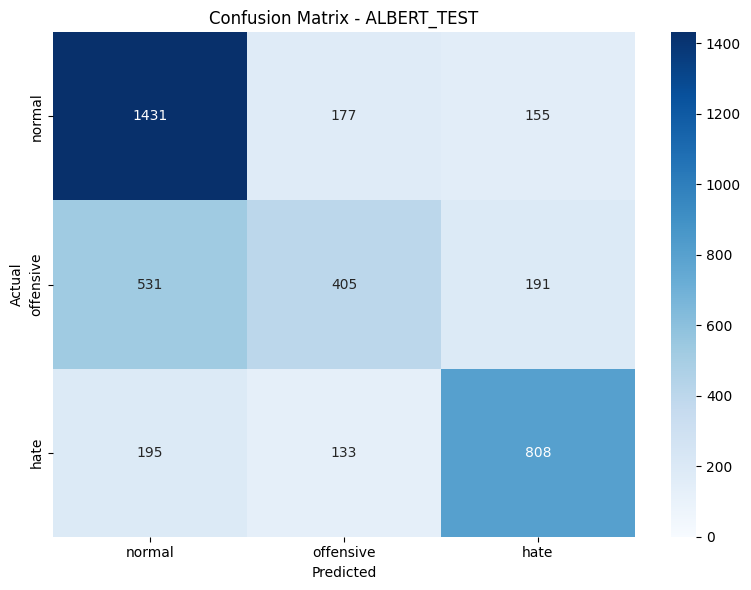

Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/11_human/output/ALBERT_TEST_roc_curve.png


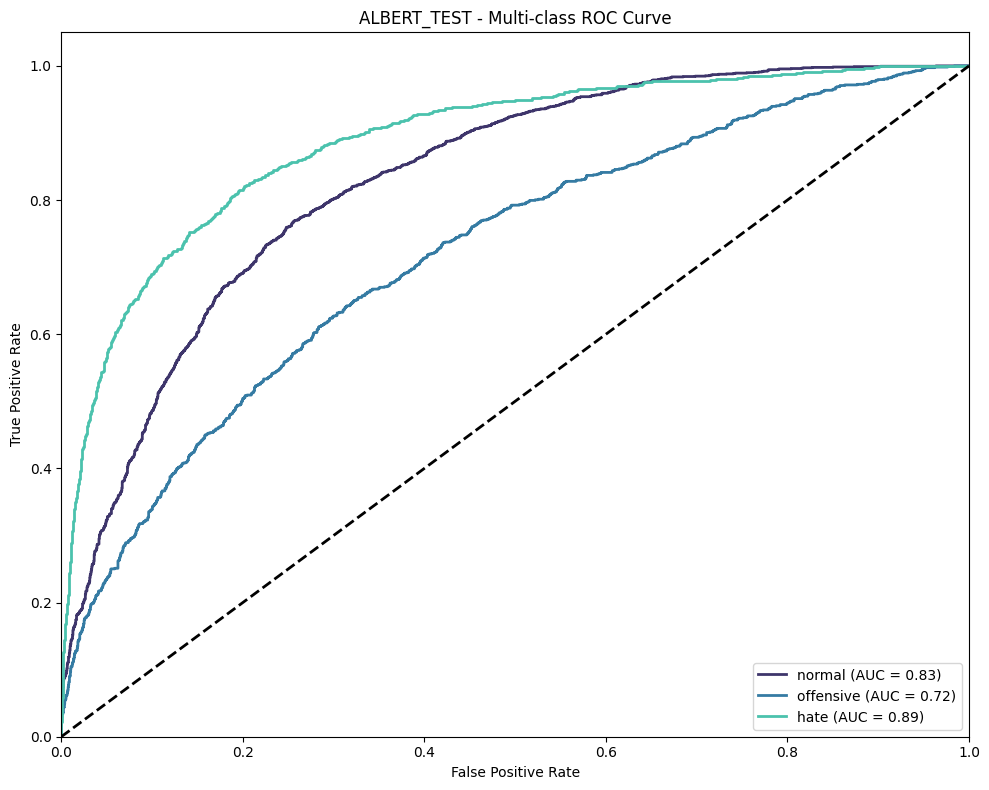


--- Evaluation (HARD): ALBERT_VAL ---

              precision    recall  f1-score   support

      normal     0.6497    0.8184    0.7243      1729
   offensive     0.5516    0.3457    0.4250      1082
        hate     0.7342    0.7070    0.7203      1215

    accuracy                         0.6577      4026
   macro avg     0.6452    0.6237    0.6232      4026
weighted avg     0.6488    0.6577    0.6427      4026

Weighted F1: 0.6432  |  95% CI: [0.6270, 0.6595]
Macro AUC(OVR): 0.8049 |  95% CI: [0.7931, 0.8158]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/11_human/output/ALBERT_VAL_confusion_matrix.png


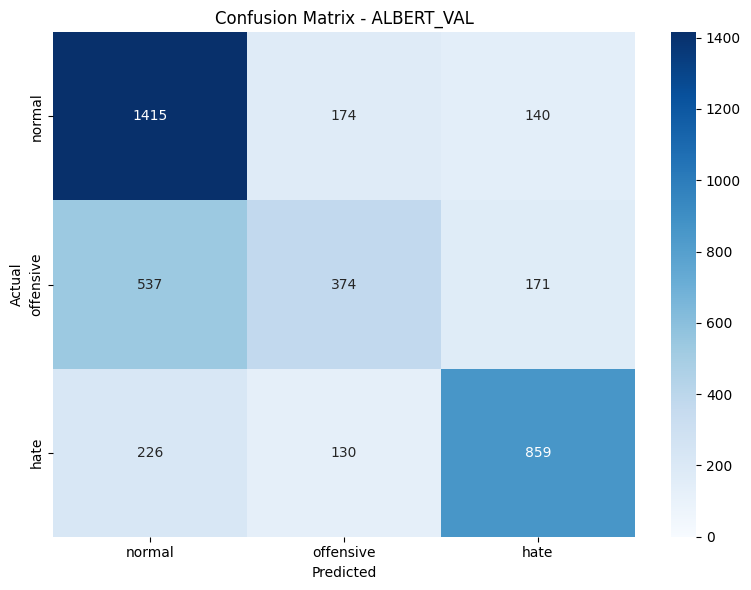

Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/01_HateSpeech/01_R1/11_human/output/ALBERT_VAL_roc_curve.png


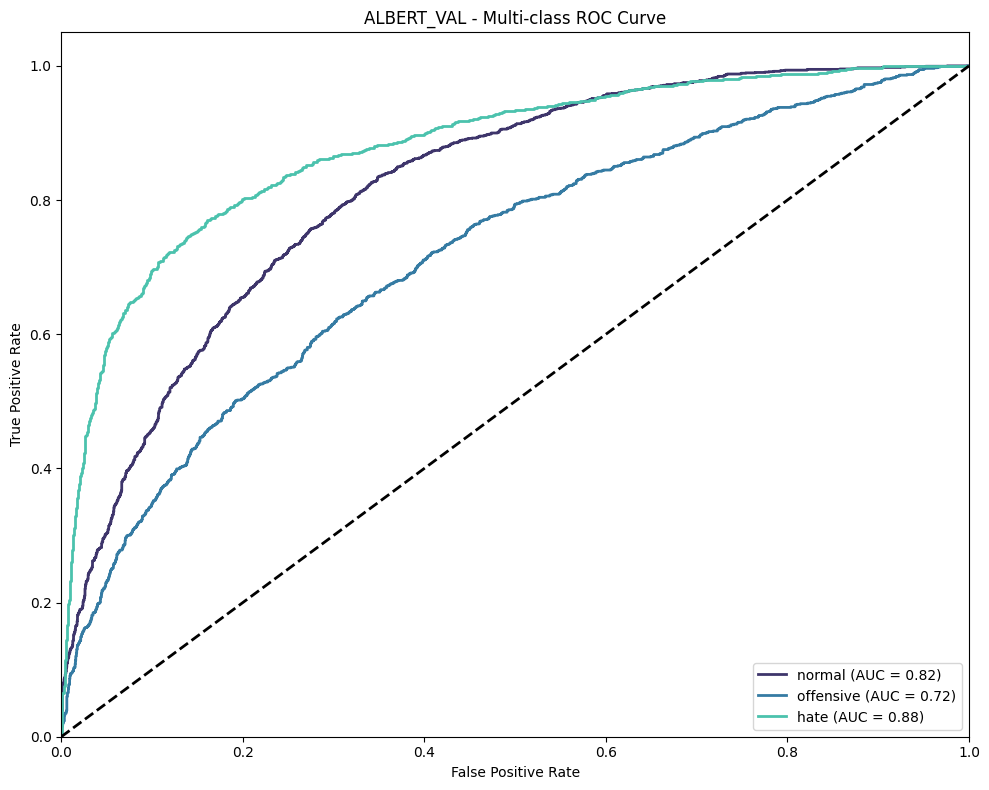


--- Evaluation (SOFT): ALBERT_TEST ---

Soft CE: 0.852204  |  95% CI: [0.835888, 0.868015]
Brier:   0.270224   |  95% CI: [0.261331, 0.279374]

--- Evaluation (SOFT): ALBERT_VAL ---

Soft CE: 0.863008  |  95% CI: [0.846112, 0.879603]
Brier:   0.271962   |  95% CI: [0.262133, 0.281028]


In [ ]:
# Convert logits -> probs once
test_probs = torch.softmax(torch.tensor(test_logits, dtype=torch.float32), dim=1).numpy()
val_probs  = torch.softmax(torch.tensor(val_logits,  dtype=torch.float32), dim=1).numpy()

# HARD evaluation + plots saved to OUTPUT_PATH
test_hard_out = evaluate_logits_hard(test_y_hard, test_logits, CLASS_NAMES, n_boot=1000, model_tag="ALBERT_TEST", save_dir=str(OUTPUT_PATH))
val_hard_out  = evaluate_logits_hard(val_y_hard,  val_logits,  CLASS_NAMES, n_boot=1000, model_tag="ALBERT_VAL",  save_dir=str(OUTPUT_PATH))

# SOFT evaluation (with CI)
test_soft_out = evaluate_probs_soft(test_probs, test_y_soft, n_boot=1000, model_tag="ALBERT_TEST")
val_soft_out  = evaluate_probs_soft(val_probs,  val_y_soft,  n_boot=1000, model_tag="ALBERT_VAL")